Downloading...
From: https://drive.google.com/uc?id=1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp
To: /content/archive.zip
100%|██████████| 34.5k/34.5k [00:00<00:00, 44.6MB/s]



Extracting main archive contents...
Extracting nested zip: extracted_data/Project4_Ag_Prediction of Agriculture Crop Production In India/Project4_Ag_Prediction of Agriculture Crop Production In India.zip
Selected CSV file: extracted_data/Project4_Ag_Prediction of Agriculture Crop Production In India/produce.csv

--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Particulars  429 non-null    object 
 1   Frequency    429 non-null    object 
 2   Unit         429 non-null    object 
 3    3-1993      3 non-null      float64
 4    3-1994      4 non-null      float64
 5    3-1995      4 non-null      float64
 6    3-1996      6 non-null      float64
 7    3-1997      10 non-null     float64
 8    3-1998      10 non-null     float64
 9    3-1999      11 non-null     float64
 10   3-2000      20 non-null     float64
 11   3-2001

/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Training Complete!

================ MODEL PERFORMANCE ================
Mean Absolute Error (MAE) : 58.81
Root Mean Squared Error (RMSE): 198.07
R² Score                  : 0.9399


<Figure size 1000x500 with 0 Axes>

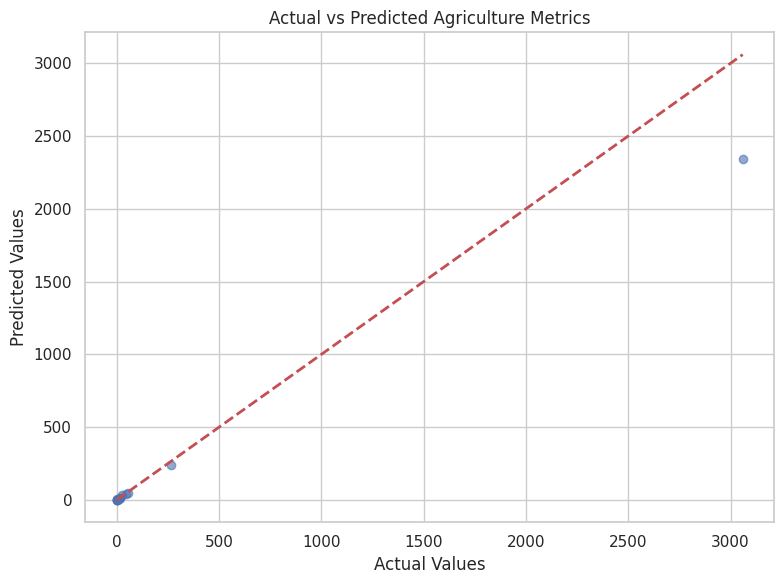

In [8]:
# ==========================================
# 1. INSTALL & IMPORT DEPENDENCIES
# ==========================================
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style
sns.set_theme(style="whitegrid")

# ==========================================
# 2. DOWNLOAD & EXTRACT ZIP FROM GOOGLE DRIVE
# ==========================================
# Drive URL: https://drive.google.com/file/d/1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp/view?usp=sharing
file_id = '1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp'
download_output = 'archive.zip'
extract_dir = 'extracted_data'

print("Downloading compressed archive from Google Drive...")
gdown.download(id=file_id, output=download_output, quiet=False)

print("\nExtracting main archive contents...")
with zipfile.ZipFile(download_output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Recursively extract any nested ZIP files
zip_found = True
while zip_found:
    zip_found = False
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file.endswith('.zip'):
                zip_path = os.path.join(root, file)
                print(f"Extracting nested zip: {zip_path}")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(root)
                os.remove(zip_path)  # Remove ZIP after extraction to avoid infinite loops
                zip_found = True
                break
        if zip_found:
            break

# Find the best CSV file. We look for 'produce.csv' first as it likely contains production metrics,
# or find a file with numerical columns.
csv_file_path = None
possible_csv_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.csv'):
            possible_csv_files.append(os.path.join(root, file))

# Prefer 'produce.csv' if it exists
for path in possible_csv_files:
    if 'produce' in path.lower():
        csv_file_path = path
        break

if not csv_file_path and possible_csv_files:
    csv_file_path = possible_csv_files[0]

if not csv_file_path:
    raise FileNotFoundError("No CSV file found inside the downloaded and unpacked archives.")

print(f"Selected CSV file: {csv_file_path}")

# Load the selected CSV file
df = pd.read_csv(csv_file_path, encoding='latin1', on_bad_lines='skip')
print("\n--- Data Overview ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

# ==========================================
# 3. DATA CLEANING & PREPROCESSING
# ==========================================
# Clean column names (strip whitespace and convert to lower)
df.columns = df.columns.str.strip().str.lower()

# Drop duplicates if any
df = df.drop_duplicates()

# Dynamically identify target column: prioritize columns related to production, yield, or any numerical column
# Avoid picking uninformative columns like index, ID, or unnamed columns
potential_targets = [col for col in df.columns if 'production' in col or 'yield' in col or 'cost' in col]
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude unnamed or index columns from targets
numerical_cols = [col for col in numerical_cols if 'unnamed' not in col and 'id' != col]

if potential_targets:
    target_col = potential_targets[0]
elif numerical_cols:
    target_col = numerical_cols[-1]
else:
    # If absolutely no valid numerical target, let's select the last column containing non-null elements
    target_col = df.columns[-1]

# Clean target variable
df = df.dropna(subset=[target_col])

# Fill missing categorical values with 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Fill missing numerical values with median
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\nTarget Variable identified as: '{target_col}'")
print("Remaining features:", list(set(df.columns) - {target_col}))

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(10, 5))
if 'state' in df.columns and target_col in df.columns:
    state_avg = df.groupby('state')[target_col].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=state_avg.values, y=state_avg.index, palette="viridis")
    plt.title(f'Top 10 States by Average {target_col.capitalize()}')
    plt.xlabel(target_col.capitalize())
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. FEATURE ENGINEERING & PIPELINE BUILD
# ==========================================
X = df.drop(columns=[target_col])
y = df[target_col]

# Separate feature types
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Define Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# Define Model Pipeline (Random Forest Regressor)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# ==========================================
# 6. TRAIN / TEST SPLIT & MODEL TRAINING
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Random Forest Regressor Model...")
model_pipeline.fit(X_train, y_train)
print("Training Complete!")

# ==========================================
# 7. MODEL EVALUATION
# ==========================================
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n================ MODEL PERFORMANCE ================")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print("===================================================")

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Agriculture Metrics')
plt.tight_layout()
plt.show()

Reshaped dataset contains 4272 rows across years 1993 to 2014.


/tmp/ipykernel_967/675189190.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette="viridis")


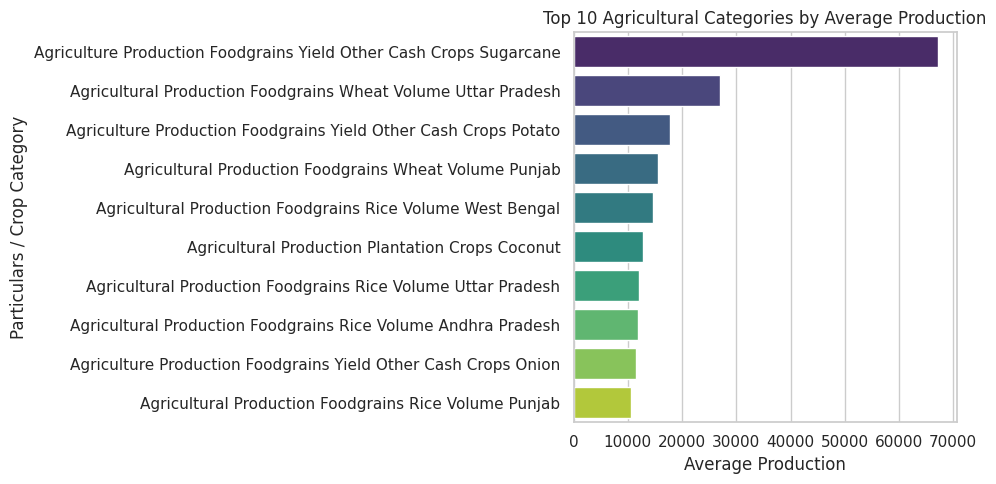


Training Random Forest Regressor Model...

================ CORRECTED MODEL PERFORMANCE ================
Mean Absolute Error (MAE) : 106.54
Root Mean Squared Error (RMSE): 325.01
R² Score                  : 0.9740


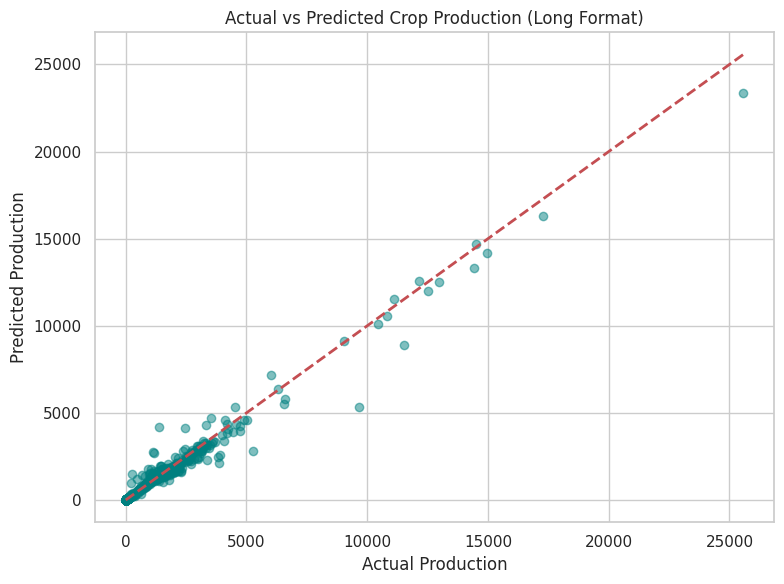

In [9]:
import gdown
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")

# 1. DOWNLOAD & EXTRACT DATASET
file_id = '1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp'
download_output = 'archive.zip'
extract_dir = 'extracted_data'

gdown.download(id=file_id, output=download_output, quiet=True)

with zipfile.ZipFile(download_output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Unzip nested archives if present
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            with zipfile.ZipFile(zip_path, 'r') as z_ref:
                z_ref.extractall(root)
            os.remove(zip_path)

# Locate produce.csv
csv_file_path = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if 'produce' in file.lower() and file.endswith('.csv'):
            csv_file_path = os.path.join(root, file)
            break

df_raw = pd.read_csv(csv_file_path, encoding='latin1', on_bad_lines='skip')
df_raw.columns = df_raw.columns.str.strip()

# 2. RESHAPE WIDE DATASET TO LONG FORMAT
id_vars = [col for col in ['Particulars', 'Frequency', 'Unit'] if col in df_raw.columns]
year_cols = [col for col in df_raw.columns if col not in id_vars]

df_long = df_raw.melt(id_vars=id_vars, value_vars=year_cols, var_name='Year_Raw', value_name='Production')

# Clean Year column into numeric integer
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4})').astype(float)
df = df_long.drop(columns=['Year_Raw']).dropna(subset=['Production', 'Year']).copy()

for col in id_vars:
    df[col] = df[col].fillna('Unknown')

print(f"Reshaped dataset contains {len(df)} rows across years {int(df['Year'].min())} to {int(df['Year'].max())}.")

# 3. EXPLORATORY DATA ANALYSIS
plt.figure(figsize=(10, 5))
top_crops = df.groupby('Particulars')['Production'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_crops.values, y=top_crops.index, palette="viridis")
plt.title('Top 10 Agricultural Categories by Average Production')
plt.xlabel('Average Production')
plt.ylabel('Particulars / Crop Category')
plt.tight_layout()
plt.show()

# 4. FEATURE ENGINEERING & PIPELINE
X = df[['Particulars', 'Frequency', 'Unit', 'Year']]
y = df['Production']

cat_features = ['Particulars', 'Frequency', 'Unit']
num_features = ['Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. TRAIN & EVALUATE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Random Forest Regressor Model...")
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n================ CORRECTED MODEL PERFORMANCE ================")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print("=============================================================")

# 6. SCATTER PLOT
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.title('Actual vs Predicted Crop Production (Long Format)')
plt.tight_layout()
plt.show()

Dataset successfully reshaped into 4272 records spanning 1993–2014.


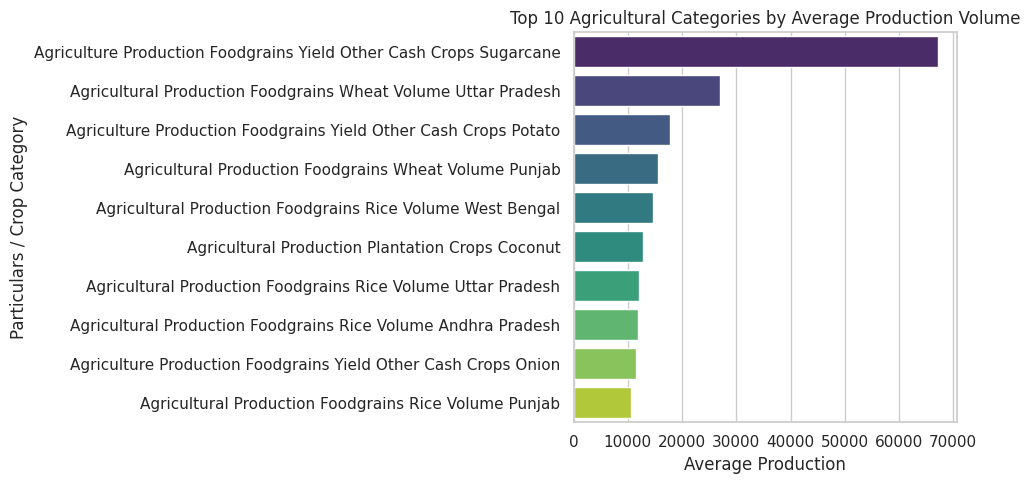


Training Random Forest Regressor Model...

================ MODEL PERFORMANCE ================
Mean Absolute Error (MAE) : 106.54
Root Mean Squared Error (RMSE): 325.01
R² Score                  : 0.9740


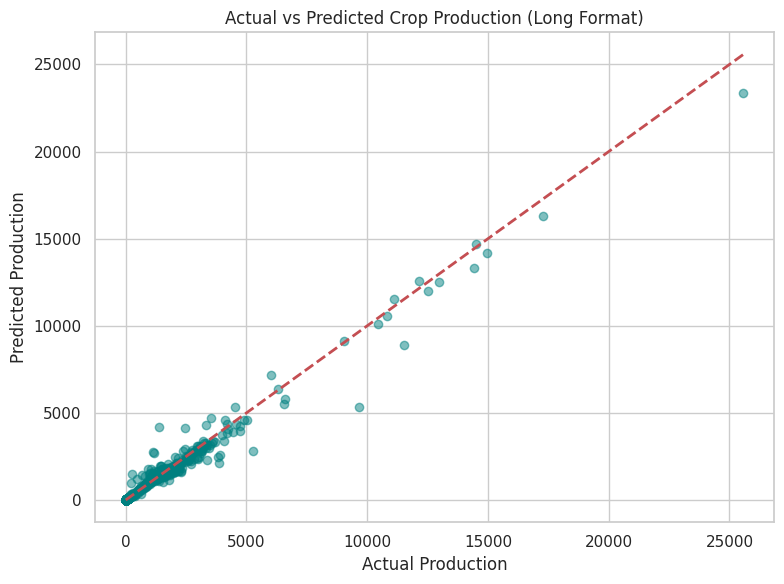

In [10]:
# ==========================================
# 1. INSTALL & IMPORT DEPENDENCIES
# ==========================================
import gdown
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style
sns.set_theme(style="whitegrid")

# ==========================================
# 2. DOWNLOAD & EXTRACT DATASET FROM DRIVE
# ==========================================
file_id = '1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp'
download_output = 'archive.zip'
extract_dir = 'extracted_data'

print("Downloading dataset archive...")
gdown.download(id=file_id, output=download_output, quiet=True)

with zipfile.ZipFile(download_output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Recursively unpack nested ZIP files
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            with zipfile.ZipFile(zip_path, 'r') as z_ref:
                z_ref.extractall(root)
            os.remove(zip_path)

# Locate produce.csv
csv_file_path = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if 'produce' in file.lower() and file.endswith('.csv'):
            csv_file_path = os.path.join(root, file)
            break

df_raw = pd.read_csv(csv_file_path, encoding='latin1', on_bad_lines='skip')
df_raw.columns = df_raw.columns.str.strip()

# ==========================================
# 3. DATA RESHAPING (WIDE TO LONG FORMAT)
# ==========================================
id_vars = [col for col in ['Particulars', 'Frequency', 'Unit'] if col in df_raw.columns]
year_cols = [col for col in df_raw.columns if col not in id_vars]

# Melt wide time-series into single Year & Production columns
df_long = df_raw.melt(id_vars=id_vars, value_vars=year_cols, var_name='Year_Raw', value_name='Production')

# Clean Year values to 4-digit integers
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4})').astype(float)
df = df_long.drop(columns=['Year_Raw']).dropna(subset=['Production', 'Year']).copy()

for col in id_vars:
    df[col] = df[col].fillna('Unknown')

print(f"Dataset successfully reshaped into {len(df)} records spanning 1993–2014.")

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(10, 5))
top_crops = df.groupby('Particulars')['Production'].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_crops.values,
    y=top_crops.index,
    hue=top_crops.index,
    palette="viridis",
    legend=False
)
plt.title('Top 10 Agricultural Categories by Average Production Volume')
plt.xlabel('Average Production')
plt.ylabel('Particulars / Crop Category')
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE ENGINEERING & MODEL PIPELINE
# ==========================================
X = df[['Particulars', 'Frequency', 'Unit', 'Year']]
y = df['Production']

cat_features = ['Particulars', 'Frequency', 'Unit']
num_features = ['Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# ==========================================
# 6. TRAINING & EVALUATION
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Random Forest Regressor Model...")
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n================ MODEL PERFORMANCE ================")
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print("===================================================")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.title('Actual vs Predicted Crop Production (Long Format)')
plt.tight_layout()
plt.show()

In [11]:
# Predict production volume for a specific crop category and year
sample_input = pd.DataFrame({
    'Particulars': ['Agricultural Production Foodgrains Wheat Volume Uttar Pradesh'],
    'Frequency': ['Annual, Ending mar Of Each Year'],
    'Unit': ['Ton mn'],
    'Year': [2024]
})

predicted_value = model_pipeline.predict(sample_input)
print(f"Predicted Production for 2024: {predicted_value[0]:.2f} {sample_input['Unit'].iloc[0]}")

Predicted Production for 2024: 30172.86 Ton mn
